In [1]:
"""
    File: modello.ipynb
    Author: Andrea Macale
    Date: 2026-03-04

    Description: Notebook per la realizzazione del modello per il suggerimento ed analisi di follow-up clinici

"""

'\n    File: modello.ipynb\n    Author: Andrea Macale\n    Date: 2026-03-04\n\n    Description: Notebook per la realizzazione del modello per il suggerimento ed analisi di follow-up clinici\n\n'

# Parte 0: Importazione delle librerie

## Librerie principali

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

## Correlazione 

In [ ]:
from sklearn.preprocessing import LabelEncoder
import scipy.stats
from scipy.stats import spearmanr


## VIF

In [4]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import statsmodels.api as sm

## Modelli di ML

# Parte 1: Estrazione dei dati

## Aperta dei file del dataset

In [5]:
pos_dataset = os.path.join(Path(os.path.abspath("modello.ipynb")).parent.parent, "data")

In [6]:
file = os.path.join(pos_dataset, "patients.csv")
pazienti = pd.read_csv(file)
pazienti['subject_id'] = pazienti['subject_id'].astype(str)
pazienti.head()

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10000032,F,52,2180,2014 - 2016,2180-09-09
1,10000048,F,23,2126,2008 - 2010,NaN
2,10000058,F,33,2168,2020 - 2022,NaN
3,10000068,F,19,2160,2008 - 2010,NaN
4,10000084,M,72,2160,2017 - 2019,2161-02-13


In [7]:
file = os.path.join(pos_dataset, "diagnoses_icd.csv")
tipi = {
    'subject_id': str, 
    'hadm_id': str, 
    'icd_code': str, 
    'icd_version': str
}
diagnosi = pd.read_csv(file, dtype=tipi)
diagnosi['icd_version'] = pd.to_numeric(diagnosi['icd_version'], errors='coerce').fillna(0).astype(int)
diagnosi = diagnosi.drop_duplicates()
diagnosi.head()

,subject_id,hadm_id,seq_num,icd_code,icd_version
0,10000032,22595853,1,5723,9
1,10000032,22595853,2,78959,9
2,10000032,22595853,3,5715,9
3,10000032,22595853,4,07070,9
4,10000032,22595853,5,496,9


In [8]:
file = os.path.join(pos_dataset, "mimic-cxr-2.0.0-metadata.csv")
metadati = pd.read_csv(file)
metadati['dicom_id'] = metadati['dicom_id'].astype(str)
metadati['subject_id'] = metadati['subject_id'].astype(str)
metadati['study_id'] = metadati['study_id'].astype(str)
metadati.head()

,dicom_id,subject_id,study_id,PerformedProcedureStepDescription,ViewPosition,Rows,Columns,StudyDate,StudyTime,ProcedureCodeSequence_CodeMeaning,ViewCodeSequence_CodeMeaning,PatientOrientationCodeSequence_CodeMeaning
0,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014,10000032,50414267,CHEST (PA AND LAT),PA,3056,2544,21800506,213014.531,CHEST (PA AND LAT),postero-anterior,Erect
1,174413ec-4ec4c1f7-34ea26b7-c5f994f8-79ef1962,10000032,50414267,CHEST (PA AND LAT),LATERAL,3056,2544,21800506,213014.531,CHEST (PA AND LAT),lateral,Erect
2,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab,10000032,53189527,CHEST (PA AND LAT),PA,3056,2544,21800626,165500.312,CHEST (PA AND LAT),postero-anterior,Erect
3,e084de3b-be89b11e-20fe3f9f-9c8d8dfe-4cfd202c,10000032,53189527,CHEST (PA AND LAT),LATERAL,3056,2544,21800626,165500.312,CHEST (PA AND LAT),lateral,Erect
4,68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714,10000032,53911762,CHEST (PORTABLE AP),AP,2705,2539,21800723,80556.875,CHEST (PORTABLE AP),antero-posterior,NaN


In [9]:
lista_referti = []
ricerca = Path(os.path.join(pos_dataset, "mimic-cxr-reports", "files"))
for file_path in ricerca.rglob('*.txt'):
    study_id = file_path.stem.replace('s', '')
    subject_id = file_path.parent.name.replace('p', '')
    with open(file_path, 'r', encoding='utf-8') as file:
        testo = file.read()
    lista_referti.append({'subject_id': subject_id, 'study_id': study_id, 'testo_referto': testo})
referti = pd.DataFrame(lista_referti)
print(f"{len(referti)} referti")
referti.head()

227835 referti


,subject_id,study_id,testo_referto
0,17015391,58847767,FINAL REPORT\...
1,17015391,51918981,FINAL REPORT\...
2,17015391,54239234,FINAL REPORT\...
3,17015391,51167371,FINAL REPORT\...
4,17015391,52622416,FINAL REPORT\...


In [10]:
lista_immagini = []
ricerca = Path(os.path.join(pos_dataset, "MIMIC_SUPER_RES_24K"))
for file_path in ricerca.rglob('*.jpg'):
    dicom_id = file_path.stem
    lista_immagini.append({'dicom_id': dicom_id, 'path_immagine': str(file_path)})
immagini = pd.DataFrame(lista_immagini)
immagini['path_immagine'] = immagini['path_immagine'].str.replace(str(pos_dataset+"/"), "data/", regex=False) # pulisci il path
immagini['dicom_id'] = immagini['dicom_id'].astype(str)
print(f"{len(immagini)} immagini")
immagini.head()

24000 immagini


,dicom_id,path_immagine
0,62456122-1887ff8c-ef1cba37-270fe1ac-c88ef7fc,data/MIMIC_SUPER_RES_24K/62456122-1887ff8c-ef1...
1,152c3005-d0c7bf7a-4c0f7935-e82aef6e-bed96e2e,data/MIMIC_SUPER_RES_24K/152c3005-d0c7bf7a-4c0...
2,c4a20cd5-94e7d182-0bbca8a9-797c8bf5-7e12e050,data/MIMIC_SUPER_RES_24K/c4a20cd5-94e7d182-0bb...
3,064741c9-95255009-ae0c53ee-ccb54164-21b77bbb,data/MIMIC_SUPER_RES_24K/064741c9-95255009-ae0...
4,2150ba84-0f87ae6f-a7132d8e-8b02fb6c-99745702,data/MIMIC_SUPER_RES_24K/2150ba84-0f87ae6f-a71...


## Prima pulizia, selezione e join dei dati

In [11]:
dataset = pazienti.merge(metadati, on=['subject_id'], how='inner')
dataset = dataset.merge(immagini, on=['dicom_id'], how='inner')
dataset = dataset.merge(referti, on=['subject_id', 'study_id'], how='inner')
print(len(dataset))
dataset

22768


,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod,dicom_id,study_id,PerformedProcedureStepDescription,ViewPosition,Rows,Columns,StudyDate,StudyTime,ProcedureCodeSequence_CodeMeaning,ViewCodeSequence_CodeMeaning,PatientOrientationCodeSequence_CodeMeaning,path_immagine,testo_referto
0,10000898,F,80,2188,2014 - 2016,NaN,2a280266-c8bae121-54d75383-cac046f4-ca37aa16,50771383,CHEST (PA AND LAT),PA,2544,3056,21880312,125501.842,CHEST (PA AND LAT),postero-anterior,Erect,data/MIMIC_SUPER_RES_24K/2a280266-c8bae121-54d...,FINAL REPORT\...
1,10000935,F,52,2182,2008 - 2010,2187-11-12,f1adcae3-2921c0a8-5d9652f9-4191ecd7-f2a96f35,56522600,NaN,PA,2022,1736,21860730,155005.000,CHEST (PA AND LAT),postero-anterior,Erect,data/MIMIC_SUPER_RES_24K/f1adcae3-2921c0a8-5d9...,FINAL REPORT\...
2,10001401,F,89,2131,2014 - 2016,NaN,0009a9fb-eb905e90-824cad7c-16d40468-007f0038,50225296,PORTABLE ABDOMEN,AP,3056,2544,21310610,102234.484,DX CHEST PORT LINE/TUBE PLCMT 1 EXAM,antero-posterior,Erect,data/MIMIC_SUPER_RES_24K/0009a9fb-eb905e90-824...,FINAL REPORT\...
3,10001401,F,89,2131,2014 - 2016,NaN,c74ce171-c7c53262-a7d57fa1-ee9a9bea-b5f75cb8,51065211,CHEST (PA AND LAT),PA,3056,2544,21310619,193047.156,CHEST (PA AND LAT),postero-anterior,Erect,data/MIMIC_SUPER_RES_24K/c74ce171-c7c53262-a7d...,FINAL REPORT\...
4,10001401,F,89,2131,2014 - 2016,NaN,d9db838d-4612fd1e-e45b40a9-3ea30033-26efd8e4,55350604,Performed Desc,PA,2021,2021,21310802,114559.000,CHEST (PA AND LAT),postero-anterior,Recumbent,data/MIMIC_SUPER_RES_24K/d9db838d-4612fd1e-e45...,FINAL REPORT\...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22763,19998330,F,71,2177,2011 - 2013,2178-12-08,05405a03-c11efc6e-8a4366b6-d929640f-c356d564,59735820,CHEST (PORTABLE AP),AP,2453,2306,21781021,170349.875,CHEST (PORTABLE AP),antero-posterior,Erect,data/MIMIC_SUPER_RES_24K/05405a03-c11efc6e-8a4...,FINAL REPORT\...
22764,19998350,M,52,2127,2011 - 2013,NaN,d14b91a7-2deb65ba-dea8e4b9-b7bbeb5e-f3ac734f,51819111,CHEST (PA AND LAT),PA,3056,2544,21280221,85427.984,CHEST (PA AND LAT),postero-anterior,Erect,data/MIMIC_SUPER_RES_24K/d14b91a7-2deb65ba-dea...,FINAL REPORT\...
22765,19999287,F,71,2191,2008 - 2010,2197-09-02,50373d1b-8df0d15f-5d0047f4-578bc509-4f2b48f0,51885769,CHEST (PORTABLE AP),AP,3056,2544,21970726,25712.640,CHEST (PORTABLE AP),antero-posterior,Erect,data/MIMIC_SUPER_RES_24K/50373d1b-8df0d15f-5d0...,FINAL REPORT\...
22766,19999287,F,71,2191,2008 - 2010,2197-09-02,46510b80-411ac511-fe6ffab2-d7dfdc76-dff1a762,52519175,CHEST (PORTABLE AP),AP,2544,3056,21970807,90637.796,CHEST (PORTABLE AP),antero-posterior,NaN,data/MIMIC_SUPER_RES_24K/46510b80-411ac511-fe6...,FINAL REPORT\...


In [ ]:
condizioni = [
    # STADIO IV: Metastasi (Il più grave)
    diagnosi['icd_code'].str.startswith(('196', '197', '198', '199', 'C77', 'C78', 'C79'), na=False),
    
    # STADIO I-III: Tumore Primario Invasivo
    diagnosi['icd_code'].str.startswith(('162', 'C34'), na=False),
    
    # BENIGNO: Tumori non maligni (ICD-9: 212.3 | ICD-10: D14.3)
    diagnosi['icd_code'].str.startswith(('2123', 'D143'), na=False),
    
    # A RISCHIO: Noduli o ombre (Sospetti non confermati)
    diagnosi['icd_code'].str.contains('793.1|R91', na=False)
]
valori = [4, 3, 2, 1]
diagnosi['numero_severita'] = np.select(condizioni, valori, default=0)
etichette_pazienti = diagnosi.groupby('subject_id')['numero_severita'].max().reset_index()
mappa_severita = {
    4: 'IV STADIO: METASTATICO',
    3: 'I-III STADIO: PRIMARIO',
    2: 'BENIGNO',
    1: 'A RISCHIO',
    0: 'NEGATIVO'
}
etichette_pazienti['stato_clinico'] = etichette_pazienti['numero_severita'].map(mappa_severita)

,stato_clinico,Conteggio
0,A RISCHIO,1394
1,I-III STADIO: PRIMARIO,496
2,IV STADIO: METASTATICO,2372
3,NEGATIVO,18506


In [13]:
dataset = dataset.merge(etichette_pazienti, on=['subject_id'], how='left')
dataset['numero_severita'] = pd.to_numeric(dataset['numero_severita'], errors='coerce')
dataset['numero_severita'] = dataset['numero_severita'].fillna(0)
dataset['numero_severita'] = dataset['numero_severita'].astype('int64')
dataset['stato_clinico'] = dataset['stato_clinico'].fillna('NEGATIVO')
dataset

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod,dicom_id,study_id,PerformedProcedureStepDescription,ViewPosition,...,Columns,StudyDate,StudyTime,ProcedureCodeSequence_CodeMeaning,ViewCodeSequence_CodeMeaning,PatientOrientationCodeSequence_CodeMeaning,path_immagine,testo_referto,numero_severita,stato_clinico
0,10000898,F,80,2188,2014 - 2016,NaN,2a280266-c8bae121-54d75383-cac046f4-ca37aa16,50771383,CHEST (PA AND LAT),PA,...,3056,21880312,125501.842,CHEST (PA AND LAT),postero-anterior,Erect,data/MIMIC_SUPER_RES_24K/2a280266-c8bae121-54d...,FINAL REPORT\...,0,NEGATIVO
1,10000935,F,52,2182,2008 - 2010,2187-11-12,f1adcae3-2921c0a8-5d9652f9-4191ecd7-f2a96f35,56522600,NaN,PA,...,1736,21860730,155005.000,CHEST (PA AND LAT),postero-anterior,Erect,data/MIMIC_SUPER_RES_24K/f1adcae3-2921c0a8-5d9...,FINAL REPORT\...,4,IV STADIO: METASTATICO
2,10001401,F,89,2131,2014 - 2016,NaN,0009a9fb-eb905e90-824cad7c-16d40468-007f0038,50225296,PORTABLE ABDOMEN,AP,...,2544,21310610,102234.484,DX CHEST PORT LINE/TUBE PLCMT 1 EXAM,antero-posterior,Erect,data/MIMIC_SUPER_RES_24K/0009a9fb-eb905e90-824...,FINAL REPORT\...,1,A RISCHIO
3,10001401,F,89,2131,2014 - 2016,NaN,c74ce171-c7c53262-a7d57fa1-ee9a9bea-b5f75cb8,51065211,CHEST (PA AND LAT),PA,...,2544,21310619,193047.156,CHEST (PA AND LAT),postero-anterior,Erect,data/MIMIC_SUPER_RES_24K/c74ce171-c7c53262-a7d...,FINAL REPORT\...,1,A RISCHIO
4,10001401,F,89,2131,2014 - 2016,NaN,d9db838d-4612fd1e-e45b40a9-3ea30033-26efd8e4,55350604,Performed Desc,PA,...,2021,21310802,114559.000,CHEST (PA AND LAT),postero-anterior,Recumbent,data/MIMIC_SUPER_RES_24K/d9db838d-4612fd1e-e45...,FINAL REPORT\...,1,A RISCHIO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22763,19998330,F,71,2177,2011 - 2013,2178-12-08,05405a03-c11efc6e-8a4366b6-d929640f-c356d564,59735820,CHEST (PORTABLE AP),AP,...,2306,21781021,170349.875,CHEST (PORTABLE AP),antero-posterior,Erect,data/MIMIC_SUPER_RES_24K/05405a03-c11efc6e-8a4...,FINAL REPORT\...,0,NEGATIVO
22764,19998350,M,52,2127,2011 - 2013,NaN,d14b91a7-2deb65ba-dea8e4b9-b7bbeb5e-f3ac734f,51819111,CHEST (PA AND LAT),PA,...,2544,21280221,85427.984,CHEST (PA AND LAT),postero-anterior,Erect,data/MIMIC_SUPER_RES_24K/d14b91a7-2deb65ba-dea...,FINAL REPORT\...,0,NEGATIVO
22765,19999287,F,71,2191,2008 - 2010,2197-09-02,50373d1b-8df0d15f-5d0047f4-578bc509-4f2b48f0,51885769,CHEST (PORTABLE AP),AP,...,2544,21970726,25712.640,CHEST (PORTABLE AP),antero-posterior,Erect,data/MIMIC_SUPER_RES_24K/50373d1b-8df0d15f-5d0...,FINAL REPORT\...,3,I-III STADIO: PRIMARIO
22766,19999287,F,71,2191,2008 - 2010,2197-09-02,46510b80-411ac511-fe6ffab2-d7dfdc76-dff1a762,52519175,CHEST (PORTABLE AP),AP,...,3056,21970807,90637.796,CHEST (PORTABLE AP),antero-posterior,NaN,data/MIMIC_SUPER_RES_24K/46510b80-411ac511-fe6...,FINAL REPORT\...,3,I-III STADIO: PRIMARIO


# Parte 2: Gestione dei valori nulli e correlazione dei dati

In [14]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22768 entries, 0 to 22767
Data columns (total 21 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   subject_id                                  22768 non-null  object 
 1   gender                                      22768 non-null  object 
 2   anchor_age                                  22768 non-null  int64  
 3   anchor_year                                 22768 non-null  int64  
 4   anchor_year_group                           22768 non-null  object 
 5   dod                                         9424 non-null   object 
 6   dicom_id                                    22768 non-null  object 
 7   study_id                                    22768 non-null  object 
 8   PerformedProcedureStepDescription           21128 non-null  object 
 9   ViewPosition                                22768 non-null  object 
 10  Rows      

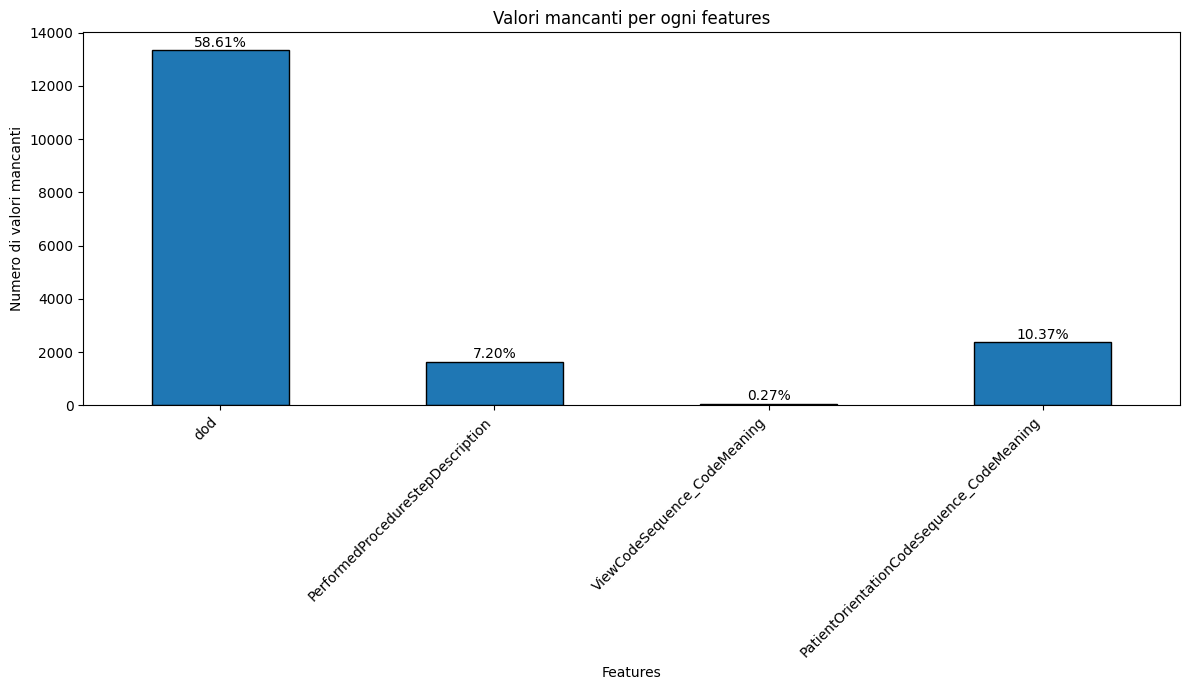

In [15]:
def plot_valori_mancanti(dataset):
    valori_nulli = dataset.isnull().sum()
    valori_nulli = valori_nulli[valori_nulli > 0]
    percentuale = valori_nulli / len(dataset) * 100
    plt.figure(figsize=(12, 7), dpi=100)
    valori_nulli.plot(kind='bar', edgecolor='black')
    for chiave, valore in enumerate(valori_nulli):
        plt.text(chiave, valore + (max(valori_nulli) * 0.01), f"{percentuale.iloc[chiave]:.2f}%", ha='center', fontsize=10)
    plt.title('Valori mancanti per ogni features')
    plt.ylabel('Numero di valori mancanti')
    plt.xlabel('Features')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
        
plot_valori_mancanti(dataset)

I valori mancanti significativi sono i seguenti:
- dod (buona parte), che rappresenta la data di morte (sicuramente rumore);
- PatientOrientationCodeSequence_CodeMeaning, che è un dato molto tecnico e spesso ridondante;
- PerformedProcedureStepDescription, anch'esso ridondante dato che ci sono i reperti testuali;
- ViewCodeSequence_CodeMeaning, ennesima ripetizione verbosa.
Per questo motivo le feature si possono eliminare tranquillamente.<br>
Inoltre altri dati superfli sono:
- Rows e Columns, perché avviene comunque la ridimensione del dataset;
- anchor_year_group ed anchor_year, poiché sono solamente dati amministrativi;
- ProcedureCodeSequence_CodeMeaning (un'altra ridondanza)

In [16]:
colonne_da_eliminare = [
    'dod',
    'PatientOrientationCodeSequence_CodeMeaning',
    'PerformedProcedureStepDescription',
    'ViewCodeSequence_CodeMeaning',
    'ProcedureCodeSequence_CodeMeaning',
    'Rows',
    'Columns',
    'anchor_year_group',
    'anchor_year'
]
dataset = dataset.drop(columns=colonne_da_eliminare, errors='ignore')
print(dataset.columns.tolist())

['subject_id', 'gender', 'anchor_age', 'dicom_id', 'study_id', 'ViewPosition', 'StudyDate', 'StudyTime', 'path_immagine', 'testo_referto', 'numero_severita', 'stato_clinico']


## Normalizzazione dei dati

In [17]:
dataset.head()

,subject_id,gender,anchor_age,dicom_id,study_id,ViewPosition,StudyDate,StudyTime,path_immagine,testo_referto,numero_severita,stato_clinico
0,10000898,F,80,2a280266-c8bae121-54d75383-cac046f4-ca37aa16,50771383,PA,21880312,125501.842,data/MIMIC_SUPER_RES_24K/2a280266-c8bae121-54d...,FINAL REPORT\...,0,NEGATIVO
1,10000935,F,52,f1adcae3-2921c0a8-5d9652f9-4191ecd7-f2a96f35,56522600,PA,21860730,155005.000,data/MIMIC_SUPER_RES_24K/f1adcae3-2921c0a8-5d9...,FINAL REPORT\...,4,IV STADIO: METASTATICO
2,10001401,F,89,0009a9fb-eb905e90-824cad7c-16d40468-007f0038,50225296,AP,21310610,102234.484,data/MIMIC_SUPER_RES_24K/0009a9fb-eb905e90-824...,FINAL REPORT\...,1,A RISCHIO
3,10001401,F,89,c74ce171-c7c53262-a7d57fa1-ee9a9bea-b5f75cb8,51065211,PA,21310619,193047.156,data/MIMIC_SUPER_RES_24K/c74ce171-c7c53262-a7d...,FINAL REPORT\...,1,A RISCHIO
4,10001401,F,89,d9db838d-4612fd1e-e45b40a9-3ea30033-26efd8e4,55350604,PA,21310802,114559.000,data/MIMIC_SUPER_RES_24K/d9db838d-4612fd1e-e45...,FINAL REPORT\...,1,A RISCHIO


In [18]:
colonne_feature = ['gender', 'anchor_age', 'ViewPosition', 'StudyDate', 'StudyTime']
feature = dataset[colonne_feature].copy()
encoder = LabelEncoder()
feature['gender'] = encoder.fit_transform(feature['gender'])
feature['ViewPosition'] = encoder.fit_transform(feature['ViewPosition'])

## Matrice di correlazione e calcolo del VIF

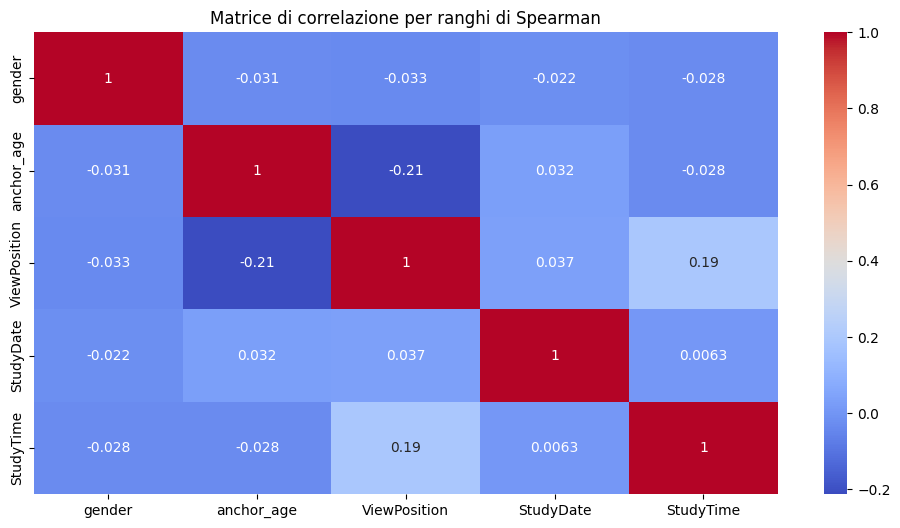

In [19]:
plt.figure(figsize=(12, 6))
plt.title('Matrice di correlazione per ranghi di Spearman')
sns.heatmap(feature.corr(method='spearman'), annot=True, cmap='coolwarm')
plt.show()

Come si può notare, non si hanno correlazioni dei dati significative. Quelle che sono leggermente più alte sono tra ViewPosition ed anchor_age e tra ViewPosition e StudyTime. Adesso, si calcolano il VIF, per verificare se è presente multicolinearità.

In [23]:
vif_data = pd.DataFrame()
vif_data['feature'] = colonne_feature
feature_const = sm.add_constant(feature)
vif_data['VIF'] = [variance_inflation_factor(feature_const.values, ind+1) for ind in range(feature.shape[1])]
print(vif_data)

        feature       VIF
0        gender  1.002925
1    anchor_age  1.052049
2  ViewPosition  1.092192
3     StudyDate  1.004138
4     StudyTime  1.039231


Come si può notare, ogni feature possiede colinearità debole, perciò è del tutto inutile eseguire procedure di riduzione di dimensionalità.

# Parte 3: Distribuzione dei dati

L'unico dato rilevante per calcolare gli outliers è l'anchor_age, poiché è l'unica variabile continua e può mostrare la demografia dei pazienti. I box-plot sugli altri dati non fornirebbe dati interessanti per il modello. Perciò, il box-plot viene fatto su anchor_age diviso per stadio_clinico, per vedere le fascie di età più colpite.

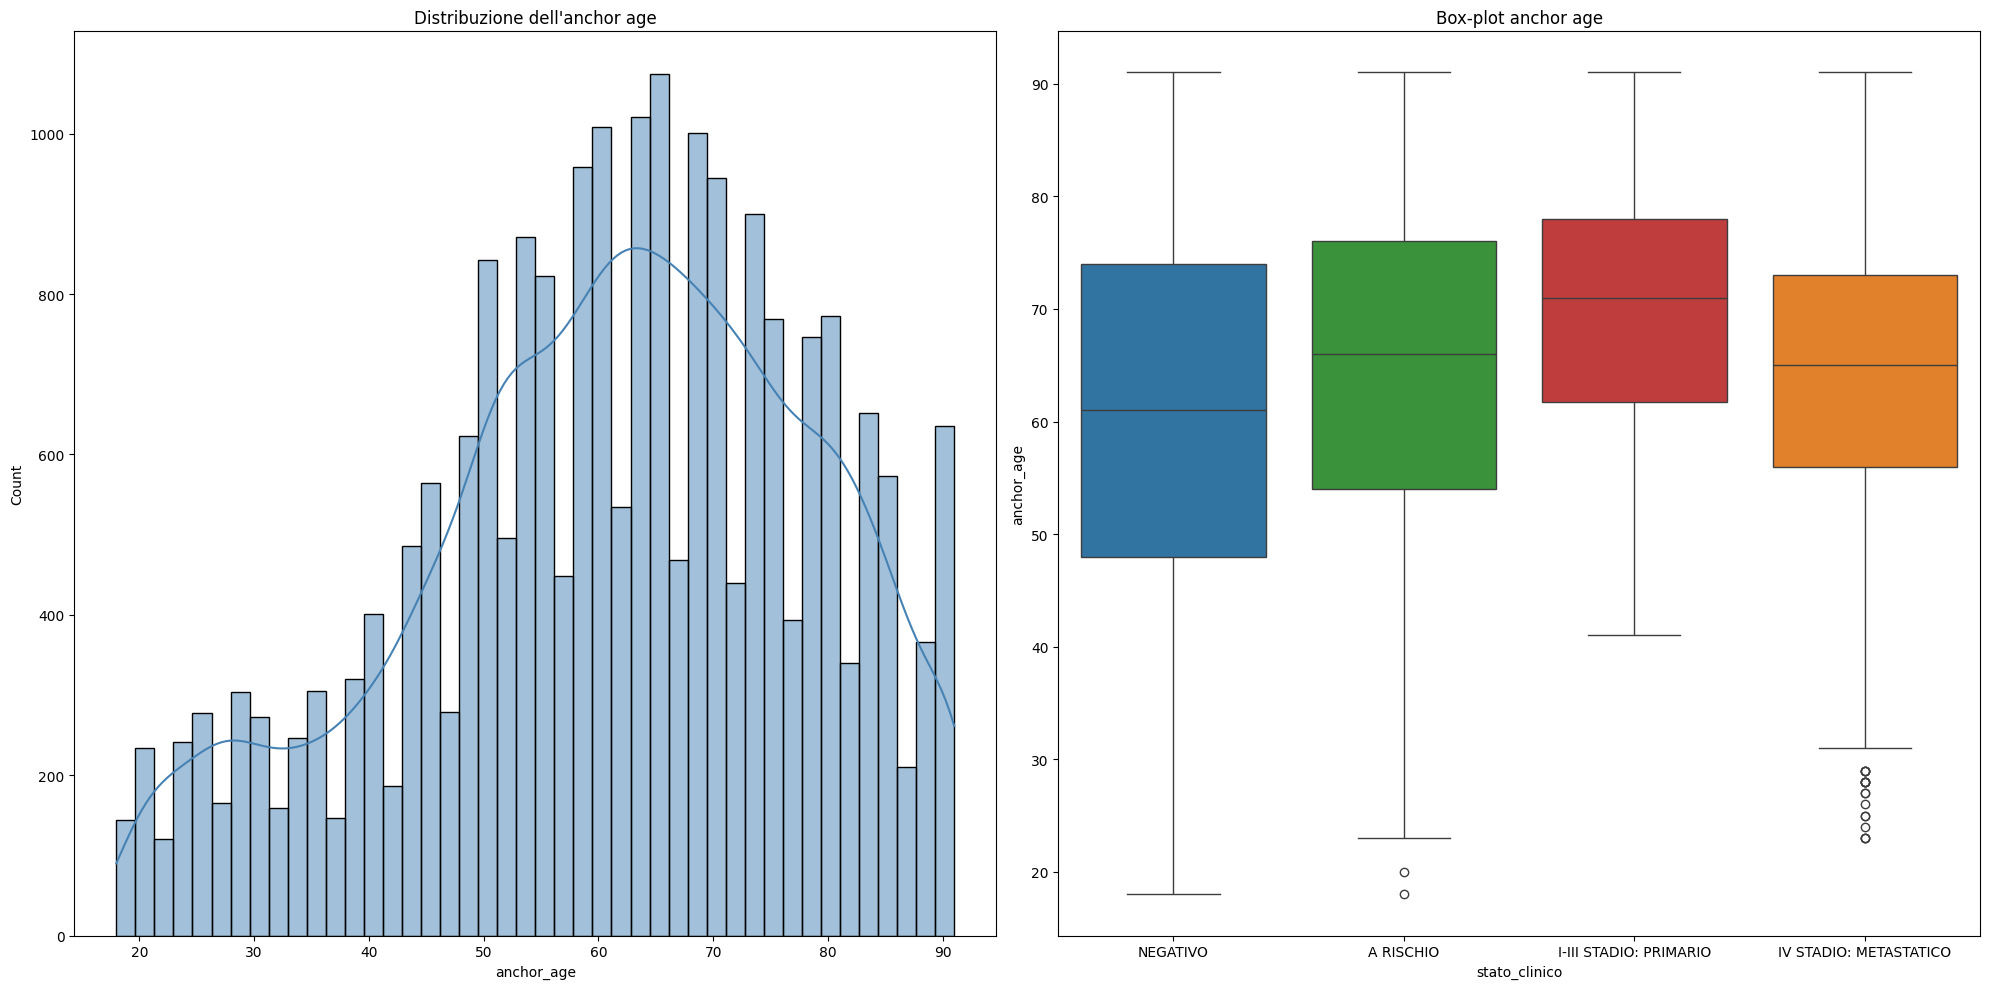

In [39]:
fig, axis = plt.subplots(1, 2, figsize=(20, 10))
ordine_clinico = [
    'NEGATIVO', 
    'A RISCHIO', 
    'I-III STADIO: PRIMARIO', 
    'IV STADIO: METASTATICO'
]
sns.histplot(dataset['anchor_age'], kde=True, ax=axis[0], color='steelblue')
sns.boxplot(x='stato_clinico', y='anchor_age', data=dataset, order=ordine_clinico ,ax=axis[1], hue='stato_clinico', legend=False)
axis[0].set_title("Distribuzione dell'anchor age")
axis[1].set_title("Box-plot anchor age")
plt.tight_layout()
plt.show()

Il grafico a sinistra mostra che la frequenza assoluta dell'età all'interno del dataset:
- concentrazione anagrafica: la distribuzione è asimmetrica, con una chiara pendenza verso le fasce d'età più alte;
- picco di incidenza: la moda del campione si colloca tra i 60 e i 65 anni, che è l'età media tipica in cui vengono prescritti esami radiologici per indagini polmonari e oncologiche;
- fasce giovani: è visibile una marcata coda a sinistra con un picco minore intorno ai 25-30 anni, che rappresenta i pazienti più giovani sottoposti a screening.

Il grafico a destra scompone l'età in base alle quattro categorie diagnostiche, permettendo di osservare le variazioni demografiche a seconda della severità della malattia:
- Negativo: essendo la classe maggioritaria di controllo, presenta una distribuzione estremamente ampia che copre l'intero range anagrafico (dai 18 ai 90 anni), con una mediana che si attesta intorno ai 61 anni;
- A Rischio: presenta una mediana più alta e una variabilità estesa;
- Stadio 0: non presenti nel dataset;
- I-III Stadio: questa classe registra la mediana più elevata del dataset, che conferma il fatto che statisticamente i tumori primari vengono diagnosticati prevalentemente nella popolazione geriatrica;
- IV Stadio: mostra molti outlier inferiori marcati, indicando un sottogruppo di pazienti eccezionalmente giovani (tra i 20 e i 30 anni) colpiti da malattia in stadio avanzato.

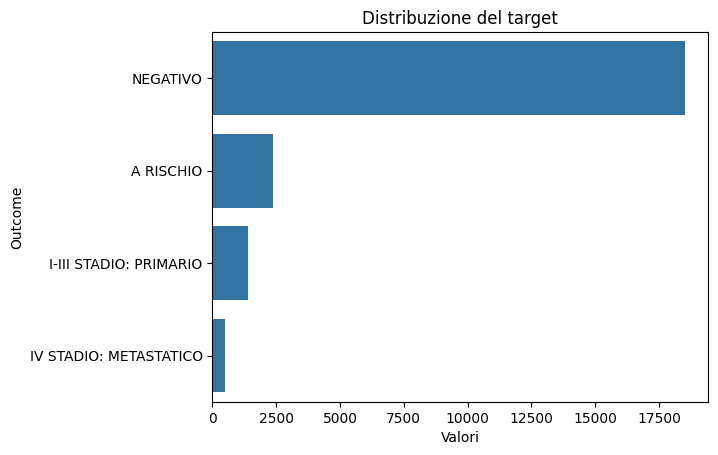

In [ ]:
def target_count():   
    target_counts = dataset['stato_clinico'].value_counts()   
    sns.barplot(x=target_counts.values, y=ordine_clinico)
    plt.title('Distribuzione del target')
    plt.xlabel('Valori')
    plt.ylabel('Numero di pazienti per stadio clinico')

    plt.show()

target_count()